# Tugas 2 (Duplikat) — Uji Anggota Klaster dari Titik Terjauh: Centroid Awal **di Dalam** vs **di Luar Layer**

**Mata Kuliah:** Data Mining

## Deskripsi
Notebook ini adalah **duplikat/varian** dari `Tugas2_KMeans_Perbandingan_Centroid.ipynb`, tapi eksperimennya difokuskan pada **titik terjauh (outlier)** dari data. Data pelanggan sama (Age & Income, tanpa standarisasi), K-Means manual dengan **K=2**.

Ide uji: ambil **titik terjauh** dari kerumunan data, lalu bandingkan apa yang terjadi kalau **centroid awal** ditaruh:
- **Skenario A — di DALAM layer** (di dalam kerumunan data / "di sekitaran itu").
- **Skenario B — di LUAR layer** (tepat di titik terjauh / outlier).

Supaya adil, **hanya satu centroid yang diubah** (C1). Centroid kedua (C2) **dibuat tetap** di titik yang sama untuk kedua skenario — jadi perbedaan hasil murni karena C1 pindah dari *dalam* ke *luar* layer.

## Dua pertanyaan yang dijawab (untuk laporan)
1. **Kalau centroid awal ditaruh di titik terjauh / outlier (di luar layer), apa yang berbeda?**
2. **Apakah anggota klaster berubah atau tetap sama?**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data pelanggan (sama dengan Tugas 2)
data = pd.DataFrame({
    'CustID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Age':    [41, 47, 33, 29, 47, 40, 38, 42, 26, 47],
    'Income': [19, 100, 57, 19, 253, 81, 56, 64, 18, 115],
})
X = data[['Age', 'Income']].values.astype(float)
label_titik = [f'P{i+1}' for i in range(len(X))]

# --- Cari TITIK TERJAUH & TITIK SENTRAL (jarak ke rata-rata data) ---
mean = X.mean(axis=0)
jarak_ke_mean = np.sqrt(((X - mean) ** 2).sum(axis=1))
idx_terjauh = int(jarak_ke_mean.argmax())   # outlier = di LUAR layer
idx_sentral = int(jarak_ke_mean.argmin())   # paling di DALAM layer

tabel_jarak = data.copy()
tabel_jarak['Jarak_ke_ratarata'] = np.round(jarak_ke_mean, 1)
tabel_jarak = tabel_jarak.sort_values('Jarak_ke_ratarata', ascending=False).reset_index(drop=True)
print('Rata-rata data (Age, Income):', tuple(np.round(mean, 1)))
print('TITIK TERJAUH (di luar layer):', label_titik[idx_terjauh], tuple(X[idx_terjauh]),
      f'-> jarak {jarak_ke_mean[idx_terjauh]:.1f}')
print('TITIK SENTRAL (di dalam layer):', label_titik[idx_sentral], tuple(X[idx_sentral]),
      f'-> jarak {jarak_ke_mean[idx_sentral]:.1f}')
tabel_jarak


Rata-rata data (Age, Income): (np.float64(39.0), np.float64(78.2))
TITIK TERJAUH (di luar layer): P5 (np.float64(47.0), np.float64(253.0)) -> jarak 175.0
TITIK SENTRAL (di dalam layer): P6 (np.float64(40.0), np.float64(81.0)) -> jarak 3.0


,CustID,Age,Income,Jarak_ke_ratarata
0,5,47,253,175.0
1,9,26,18,61.6
2,4,29,19,60.0
3,1,41,19,59.2
4,10,47,115,37.7
5,2,47,100,23.2
6,7,38,56,22.2
7,3,33,57,22.0
8,8,42,64,14.5
9,6,40,81,3.0


## Menentukan "layer" dan dua skenario

**"Layer" = kerumunan data utama** (semua titik kecuali si outlier terjauh). Titik terjauh **P5 (47, 253)** jelas nangkring jauh di atas (Income 253 vs Income lain 18–115), jadi ia berada **di luar layer**.

Dua skenario centroid awal (K=2), dengan **C2 dibuat sama** (jangkar tetap = **P2**, salah satu titik di dalam layer):

| | Centroid C1 | Centroid C2 (tetap) |
|---|---|---|
| **A — DALAM layer** | titik sentral **P6 (40, 81)** | **P2 (47, 100)** |
| **B — LUAR layer** | titik terjauh **P5 (47, 253)** | **P2 (47, 100)** |

Hanya **C1** yang berpindah dari *dalam* ke *luar* layer, sehingga efeknya bisa dibaca murni.


In [2]:
def euclid(a, b):
    return np.sqrt(np.sum((np.array(a) - np.array(b)) ** 2))

def kmeans_manual(X, centroids_awal, max_iter=20):
    centroids = np.array(centroids_awal, dtype=float)
    history = []
    for it in range(max_iter):
        labels = np.array([int(np.argmin([euclid(x, c) for c in centroids])) for x in X])
        history.append({'centroids': centroids.copy(), 'labels': labels.copy()})
        new_c = np.array([X[labels == k].mean(axis=0) if (labels == k).any() else centroids[k]
                          for k in range(len(centroids))])
        if np.allclose(new_c, centroids):
            break
        centroids = new_c
    return centroids, labels, history

C2_tetap = X[1]                          # P2 -> jangkar tetap (di dalam layer)
initA = [X[idx_sentral], C2_tetap]       # A: C1 = P6 (dalam layer)
initB = [X[idx_terjauh], C2_tetap]       # B: C1 = P5 (luar layer / terjauh)

cA, labA, histA = kmeans_manual(X, initA)
cB, labB, histB = kmeans_manual(X, initB)

def anggota(lab):
    g = {0: [], 1: []}
    for i, k in enumerate(lab):
        g[k].append(label_titik[i])
    return g
gA, gB = anggota(labA), anggota(labB)

print('Skenario A (DALAM layer) :', gA, f'-> {len(gA[0])} : {len(gA[1])}')
print('Skenario B (LUAR layer)  :', gB, f'-> {len(gB[0])} : {len(gB[1])}')
print('Anggota klaster BERUBAH?', 'YA' if not np.array_equal(labA, labB) else 'TIDAK')


Skenario A (DALAM layer) : {0: ['P1', 'P3', 'P4', 'P6', 'P7', 'P8', 'P9'], 1: ['P2', 'P5', 'P10']} -> 7 : 3
Skenario B (LUAR layer)  : {0: ['P5'], 1: ['P1', 'P2', 'P3', 'P4', 'P6', 'P7', 'P8', 'P9', 'P10']} -> 1 : 9
Anggota klaster BERUBAH? YA


## Tabel Perbandingan

In [3]:
tabel = pd.DataFrame({
    'Aspek': [
        'Centroid awal C1', 'Centroid awal C2', 'Posisi C1', 'Jumlah iterasi',
        'Centroid akhir C1', 'Centroid akhir C2',
        'Pembagian klaster', 'Anggota Klaster 1', 'Anggota Klaster 2', 'Kualitas hasil',
    ],
    'A — DALAM layer (C1 = P6)': [
        f'{tuple(initA[0])}', f'{tuple(initA[1])}', 'di dalam kerumunan', len(histA),
        f'{np.round(cA[0],1)}', f'{np.round(cA[1],1)}',
        f'{len(gA[0])} : {len(gA[1])}', ', '.join(gA[0]), ', '.join(gA[1]),
        'Baik (dua kelompok wajar)',
    ],
    'B — LUAR layer (C1 = P5 terjauh)': [
        f'{tuple(initB[0])}', f'{tuple(initB[1])}', 'di outlier (luar layer)', len(histB),
        f'{np.round(cB[0],1)}', f'{np.round(cB[1],1)}',
        f'{len(gB[0])} : {len(gB[1])}', ', '.join(gB[0]), ', '.join(gB[1]),
        'Buruk (outlier sendirian)',
    ],
})
with pd.option_context('display.max_colwidth', None):
    display(tabel)


,Aspek,A — DALAM layer (C1 = P6),B — LUAR layer (C1 = P5 terjauh)
0,Centroid awal C1,"(np.float64(40.0), np.float64(81.0))","(np.float64(47.0), np.float64(253.0))"
1,Centroid awal C2,"(np.float64(47.0), np.float64(100.0))","(np.float64(47.0), np.float64(100.0))"
2,Posisi C1,di dalam kerumunan,di outlier (luar layer)
3,Jumlah iterasi,2,2
4,Centroid akhir C1,[35.6 44.9],[ 47. 253.]
5,Centroid akhir C2,[ 47. 156.],[38.1 58.8]
6,Pembagian klaster,7 : 3,1 : 9
7,Anggota Klaster 1,"P1, P3, P4, P6, P7, P8, P9",P5
8,Anggota Klaster 2,"P2, P5, P10","P1, P2, P3, P4, P6, P7, P8, P9, P10"
9,Kualitas hasil,Baik (dua kelompok wajar),Buruk (outlier sendirian)


## Visualisasi Berdampingan

Kotak putus-putus = **"layer"** (kerumunan data utama, tanpa si outlier). ★ emas = **centroid awal**, ✖ hitam = **centroid akhir**. Terlihat jelas di skenario B centroid awal C1 berada **di luar kotak** (di titik terjauh).

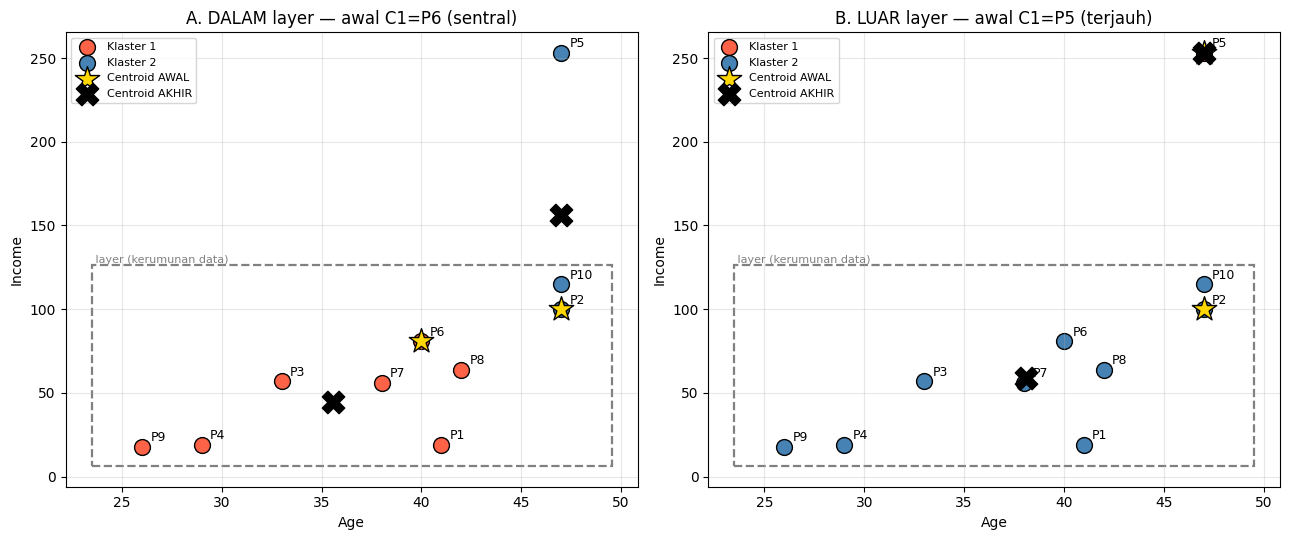

In [4]:
# Batas "layer" = kotak yang membungkus semua titik KECUALI si outlier terjauh
mask_layer = np.arange(len(X)) != idx_terjauh
lo = X[mask_layer].min(axis=0); hi = X[mask_layer].max(axis=0)
pad = (hi - lo) * 0.12
lo, hi = lo - pad, hi + pad

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
warna = ['tomato', 'steelblue']
for ax, (judul, lab, cen, init) in zip(axes, [
        ('A. DALAM layer — awal C1=P6 (sentral)', labA, cA, initA),
        ('B. LUAR layer — awal C1=P5 (terjauh)', labB, cB, initB)]):
    # kotak layer
    ax.add_patch(plt.Rectangle((lo[0], lo[1]), hi[0]-lo[0], hi[1]-lo[1],
                 fill=False, ls='--', ec='gray', lw=1.6))
    ax.text(lo[0], hi[1], ' layer (kerumunan data)', va='bottom', ha='left',
            fontsize=8, color='gray')
    for k in range(2):
        pts = X[lab == k]
        ax.scatter(pts[:, 0], pts[:, 1], c=warna[k], s=130, edgecolors='k', label=f'Klaster {k+1}')
    ax.scatter([c[0] for c in init], [c[1] for c in init], marker='*', s=340,
               c='gold', edgecolors='k', label='Centroid AWAL', zorder=5)
    ax.scatter(cen[:, 0], cen[:, 1], marker='X', s=260, c='black', label='Centroid AKHIR', zorder=5)
    for i, x in enumerate(X):
        ax.annotate(label_titik[i], (x[0], x[1]), textcoords='offset points', xytext=(6, 4), fontsize=9)
    ax.set_xlabel('Age'); ax.set_ylabel('Income'); ax.set_title(judul)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Visualisasi Tiap Iterasi

Keadaan klaster **di setiap iterasi** untuk kedua skenario. ✖ hitam = centroid yang dipakai meng-assign titik pada iterasi itu; warna titik = klaster hasil assign. Iterasi terakhir = keadaan saat konvergen.

Skenario A (DALAM layer) konvergen dalam 2 iterasi:


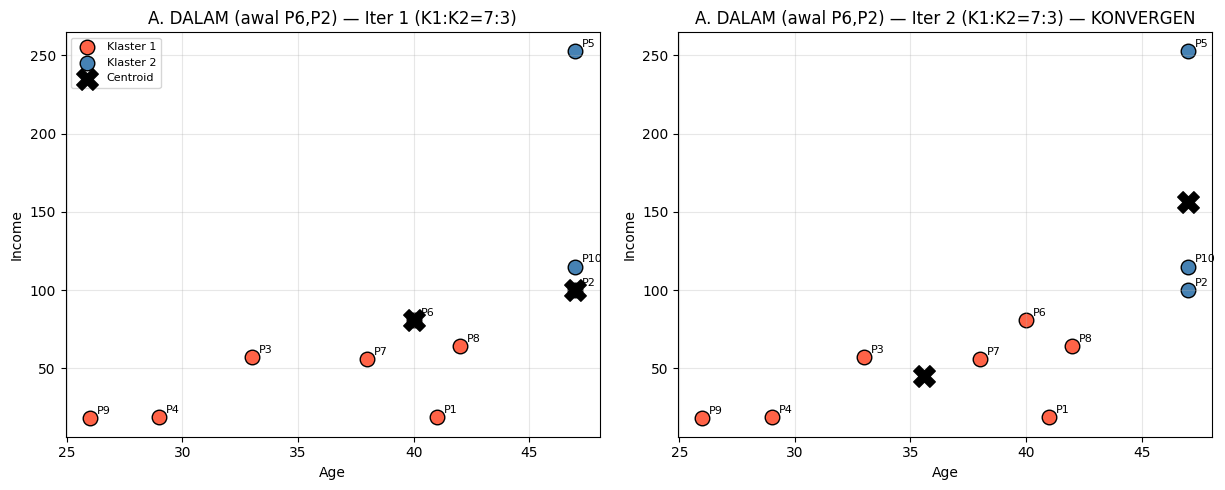

Skenario B (LUAR layer) konvergen dalam 2 iterasi:


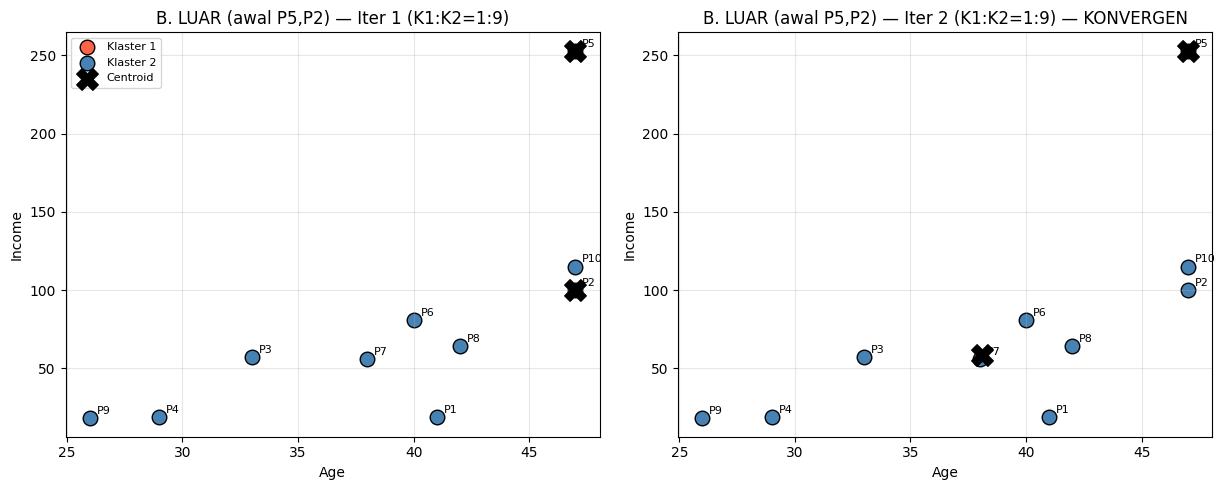

In [5]:
def plot_iters(hist, nama):
    n = len(hist)
    fig, axes = plt.subplots(1, n, figsize=(6.2 * n, 5))
    if n == 1:
        axes = [axes]
    warna = ['tomato', 'steelblue']
    for t, (ax, h) in enumerate(zip(axes, hist)):
        cen, lab = h['centroids'], h['labels']
        for k in range(2):
            pts = X[lab == k]
            ax.scatter(pts[:, 0], pts[:, 1], c=warna[k], s=110, edgecolors='k', label=f'Klaster {k+1}')
        ax.scatter(cen[:, 0], cen[:, 1], marker='X', s=240, c='black', zorder=5, label='Centroid')
        for i, x in enumerate(X):
            ax.annotate(label_titik[i], (x[0], x[1]), textcoords='offset points', xytext=(5, 3), fontsize=8)
        jml = [int((lab == 0).sum()), int((lab == 1).sum())]
        extra = ' — KONVERGEN' if t == len(hist) - 1 else ''
        ax.set_title(f'{nama} — Iter {t+1} (K1:K2={jml[0]}:{jml[1]}){extra}')
        ax.set_xlabel('Age'); ax.set_ylabel('Income'); ax.grid(alpha=0.3)
        if t == 0:
            ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

print(f'Skenario A (DALAM layer) konvergen dalam {len(histA)} iterasi:')
plot_iters(histA, 'A. DALAM (awal P6,P2)')

print(f'Skenario B (LUAR layer) konvergen dalam {len(histB)} iterasi:')
plot_iters(histB, 'B. LUAR (awal P5,P2)')


## Kesimpulan — Jawaban 2 Pertanyaan

**1. Kalau centroid awal ditaruh di TITIK TERJAUH / outlier (di luar layer), apa yang berbeda?**
Outlier **P5 (47, 253)** langsung jadi **klaster sendirian** (isinya cuma 1 anggota: P5). Pembagian yang tadinya sehat (**7 : 3**, kelompok income-rendah vs income-tinggi) **kolaps** menjadi **1 : 9** — satu klaster cuma outlier, satu klaster menumpuk 9 titik sisanya. Struktur klaster jadi tidak informatif.

**2. Anggota klaster berubah atau tidak?**
**BERUBAH total.** Dari **7 : 3** (centroid C1 di dalam layer) menjadi **1 : 9** (centroid C1 di luar layer / di outlier). Padahal yang diubah **hanya C1** (C2 tetap P2) — cukup memindah satu centroid ke outlier untuk merusak seluruh pembagian.

---

### Penjelasan Sederhana

Anggap centroid itu **"ketua kelompok"**, tiap titik ikut ketua yang **paling dekat**.

1. **P5 titik yang "jauh sendiri".** Income-nya 253, jauh di atas titik lain (18–115). Ia ada **di luar layer**.
2. **Saat P5 dijadikan ketua (centroid awal), tak ada yang mau ikut.** Semua titik lain ada di bawah, jadi mereka lebih dekat ke ketua satunya (C2). Akibatnya **9 titik gabung ke C2**, **P5 sendirian**.
3. **Ketua K1 tak bisa bergerak.** Aturan K-Means: ketua pindah ke rata-rata anggotanya. Anggota K1 cuma P5, jadi rata-ratanya = P5 sendiri → centroid **beku** di P5.
4. **Sebaliknya, saat C1 di dalam layer (P6),** dua ketua sama-sama di tengah kerumunan, "berebut" anggota dengan adil, dan menghasilkan pembagian wajar income-rendah vs income-tinggi (7 : 3).

**Intinya:** menaruh centroid awal di titik terjauh/outlier (di luar layer) membuat centroid itu **terkucil**, dan hasil klaster jadi buruk. Inilah bukti K-Means **sensitif terhadap centroid awal & outlier**.

**Solusi praktis:** **standarisasi data** (agar Income tak mendominasi) + **k-means++** (pilih centroid awal menyebar, hindari outlier) + **n_init banyak** (coba beberapa inisialisasi, ambil hasil terbaik).
